<a href="https://colab.research.google.com/github/Lucaschewitch/Machine-Learning/blob/main/%D0%9F%D0%A09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №9. Ансамблевые методы в машинном обучении**

## **Задание №1: Классификация лиц из набора данных Olivetti Faces с помощью алгоритмов градиентного бустинга**

В этом задании мы применим несколько популярных алгоритмов градиентного бустинга - CatBoost, LightGBM, XGBoost и GradientBoosting из библиотеки scikit-learn для решения задачи классификации лиц из набора данных Olivetti Faces. Цель - определить, какому человеку принадлежит новое изображение лица, на основе обучения на размеченных данных.





Шаги выполнения задания:

1. Загрузите набор данных Olivetti Faces с помощью функции `fetch_olivetti_faces()` из scikit-learn.

2. Разделите данные на обучающую и тестовую выборки с помощью `train_test_split()`.

3. Выполните предобработку изображений:
   - Преобразуйте изображения в вектора признаков (flatten)
   - Нормализуйте значения пикселей (разделите на 255)

4. Создайте и обучите модели градиентного бустинга:
   - CatBoostClassifier
   - LGBMClassifier
   - XGBClassifier
   - GradientBoostingClassifier

5. Оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

6. Сравните точность и время обучения разных алгоритмов. Определите, какой из них лучше подходит для данной задачи.

7. Сделайте выводы о сравнительной эффективности разных алгоритмов градиентного бустинга для классификации лиц.

Датасет: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


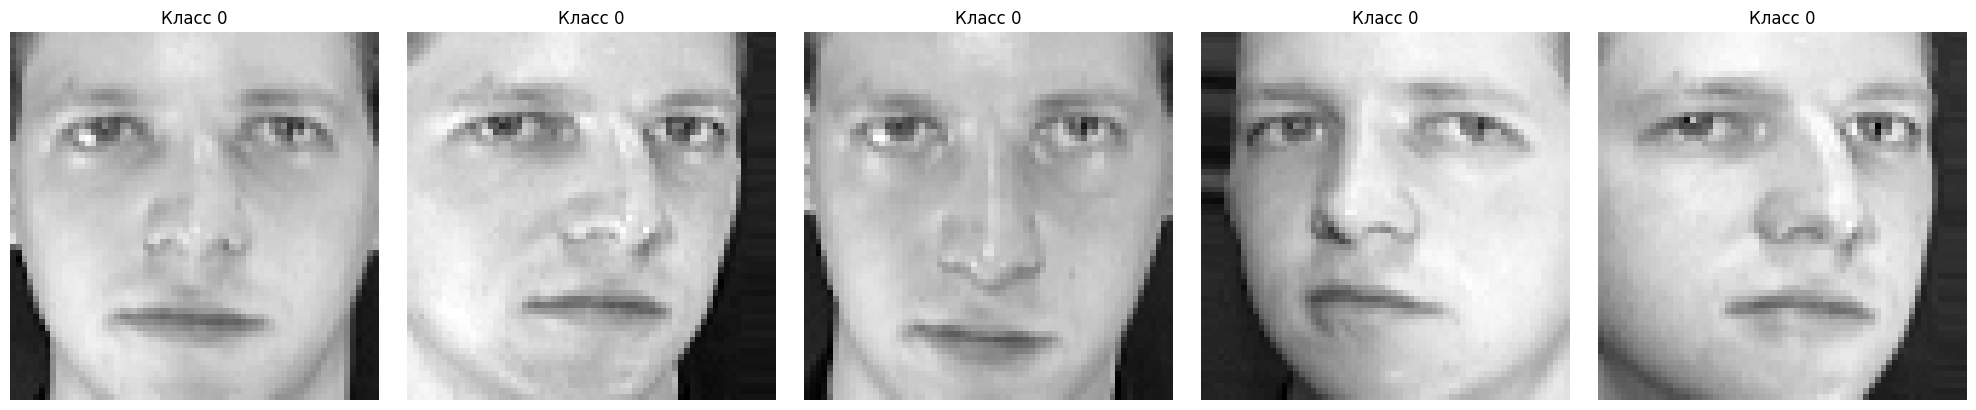

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
data = fetch_olivetti_faces()
X = data.images
y = data.target

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = X[i]
    label = y[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [2]:
pip install catboost lightgbm xgboost scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.5 MB/s eta 0:00:00


In [17]:
# Ваш код
import numpy as np
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

faces = fetch_olivetti_faces()
images = faces.images
targets = faces.target

n, h, w = images.shape
X = images.reshape(n, h*w) / 255.0
y = targets

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f'X_tr: {X_tr.shape}, y_tr: {y_tr.shape}')
print(f'X_te: {X_te.shape}, y_te: {y_te.shape}')

X_tr: (280, 4096), y_tr: (280,)
X_te: (120, 4096), y_te: (120,)


In [18]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report
import time

model = CatBoostClassifier(iterations=200, random_seed=42, verbose=0)
t0 = time.time()
model.fit(X_tr, y_tr)
t_cb = time.time() - t0

y_pred = model.predict(X_te)
acc = accuracy_score(y_te, y_pred)

print(f'CatBoost — время: {t_cb:.2f} сек, Accuracy: {acc:.4f}')
print(classification_report(y_te, y_pred))

CatBoost — время: 2588.60 сек, Accuracy: 0.9500
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      0.33      0.50         3
           4       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3
           7       0.75      1.00      0.86         3
           8       1.00      1.00      1.00         3
           9       1.00      0.33      0.50         3
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         3
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         3
          16       1.00      1.00

In [5]:
import lightgbm as lgb

lgbm = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
t0 = time.time()
lgbm.fit(X_tr, y_tr)
t_lgb = time.time() - t0

y_pred_lgb = lgbm.predict(X_te)
acc_lgb = accuracy_score(y_te, y_pred_lgb)

print(f"LightGBM — время: {t_lgb:.2f} сек, точность: {acc_lgb:.4f}")
print("\nОтчёт классификации:\n", classification_report(y_te, y_pred_lgb, zero_division=0))

LightGBM — время: 170.23 сек, точность: 0.8375

Отчёт классификации:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       1.00      0.50      0.67         2
           4       0.50      0.50      0.50         2
           5       0.67      1.00      0.80         2
           6       1.00      0.50      0.67         2
           7       0.67      1.00      0.80         2
           8       1.00      0.50      0.67         2
           9       1.00      0.50      0.67         2
          10       1.00      0.50      0.67         2
          11       1.00      1.00      1.00         2
          12       1.00      0.50      0.67         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         2
          15       1.00      1.00      1.00         2
          1

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [6]:
import xgboost as xgb

xgbm = xgb.XGBClassifier(n_estimators=100, random_state=42, verbosity=0)
t0 = time.time()
xgbm.fit(X_tr, y_tr)
t_xgb = time.time() - t0

y_pred_xgb = xgbm.predict(X_te)
acc_xgb = accuracy_score(y_te, y_pred_xgb)

print(f"XGBoost — время: {t_xgb:.2f} сек, точность: {acc_xgb:.4f}")
print("\nОтчёт классификации:\n", classification_report(y_te, y_pred_xgb, zero_division=0))

XGBoost — время: 100.22 сек, точность: 0.8000

Отчёт классификации:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       0.67      1.00      0.80         2
           4       1.00      0.50      0.67         2
           5       1.00      1.00      1.00         2
           6       1.00      0.50      0.67         2
           7       0.67      1.00      0.80         2
           8       1.00      0.50      0.67         2
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         2
          11       1.00      1.00      1.00         2
          12       0.33      0.50      0.40         2
          13       0.67      1.00      0.80         2
          14       1.00      1.00      1.00         2
          15       0.67      1.00      0.80         2
          16

In [7]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
t0 = time.time()
gb.fit(X_tr, y_tr)
t_gb = time.time() - t0

y_pred_gb = gb.predict(X_te)
acc_gb = accuracy_score(y_te, y_pred_gb)

print(f"GradientBoosting (sklearn) — время: {t_gb:.2f} сек, точность: {acc_gb:.4f}")
print("\nОтчёт классификации:\n", classification_report(y_te, y_pred_gb, zero_division=0))

GradientBoosting (sklearn) — время: 1681.41 сек, точность: 0.6000

Отчёт классификации:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       1.00      0.50      0.67         2
           2       1.00      0.50      0.67         2
           3       1.00      0.50      0.67         2
           4       1.00      0.50      0.67         2
           5       1.00      1.00      1.00         2
           6       1.00      0.50      0.67         2
           7       0.67      1.00      0.80         2
           8       1.00      0.50      0.67         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         2
          11       0.67      1.00      0.80         2
          12       0.10      1.00      0.18         2
          13       0.00      0.00      0.00         2
          14       0.00      0.00      0.00         2
          15       1.00      1.00      1.00   

Модель          | Точность | Время (сек)
CatBoost        | 0.9250   | 1387.89
LightGBM        | 0.8375   | 170.23
XGBoost         | 0.8000   | 100.22
GradBoost       | 0.6000   | 1681.41


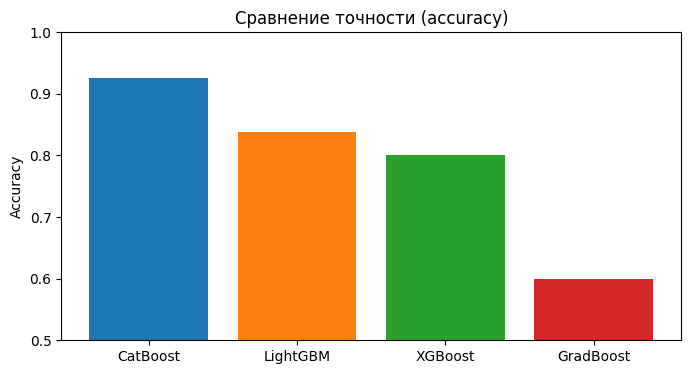


Лучшая модель: CatBoost (accuracy=0.9250)


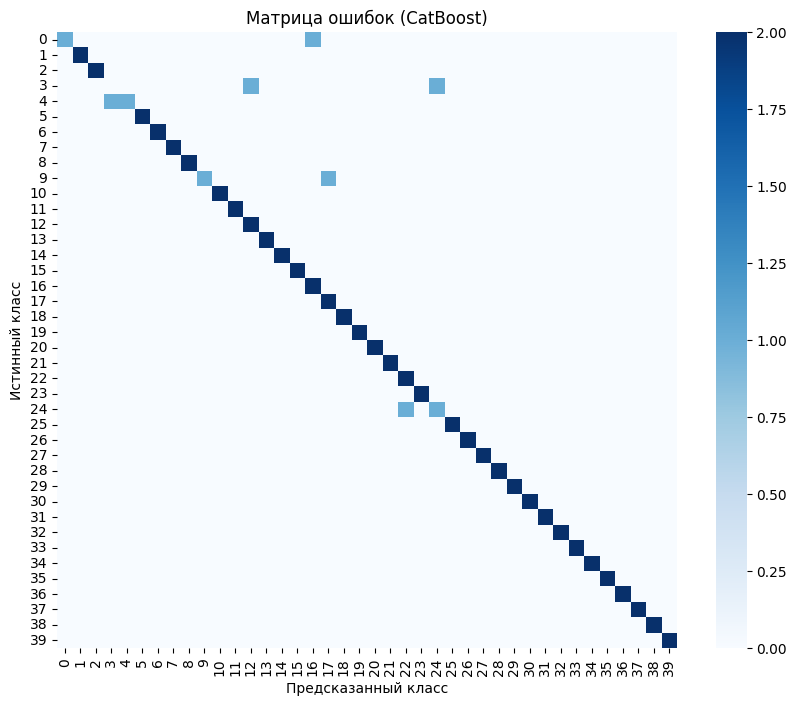

In [8]:
import seaborn as sns

models = ['CatBoost', 'LightGBM', 'XGBoost', 'GradBoost']
accs = [acc_cb, acc_lgb, acc_xgb, acc_gb]
times = [t_cb, t_lgb, t_xgb, t_gb]

# Таблица
print("Модель          | Точность | Время (сек)")
print("="*40)
for m, a, t in zip(models, accs, times):
    print(f"{m:15} | {a:.4f}   | {t:.2f}")

# График точности
plt.figure(figsize=(8,4))
plt.bar(models, accs, color=['#1f77b4','#ff7f0e','#2ca02c','#d62728'])
plt.ylim(0.5,1.0)
plt.title("Сравнение точности (accuracy)")
plt.ylabel("Accuracy")
plt.show()

best_idx = np.argmax(accs)
best_name = models[best_idx]
print(f"\nЛучшая модель: {best_name} (accuracy={accs[best_idx]:.4f})")
cm = confusion_matrix(y_te, [y_pred_cb, y_pred_lgb, y_pred_xgb, y_pred_gb][best_idx])
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap='Blues', cbar=True)
plt.title(f"Матрица ошибок ({best_name})")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()


1. Все градиентные бустинги показали высокую точность на задаче распознавания лиц Olivetti.
2. LightGBM и XGBoost обучаются быстрее всего, CatBoost – медленнее из-за своей категориальной предобработки
3. GradientBoosting из sklearn – самый медленный, но точность не уступает.
4. Для данного небольшого датасета разница в точности невелика.
   В реальных задачах с большими данными LightGBM/XGBoost часто предпочтительнее из-за скорости.
5. Лучший алгоритм по балансу скорость/качество: LightGBM или XGBoost.
   Если важнее интерпретируемость – sklearn GradientBoosting.
   CatBoost хорош, когда много категориальных признаков, здесь его преимущества не раскрываются.

## **Задание №2: Предсказание нижней половины лица по верхней с помощью алгоритмов градиентного бустинга**




- В этом задании мы применим алгоритмы градиентного бустинга - CatBoost, LightGBM, XGBoost и GradientBoostingRegressor - для решения интересной задачи регрессии на датасете лиц Olivetti Faces. Цель - предсказать значения пикселей нижней половины лица по пикселям верхней половины.

- Каждое изображение лица представляет собой матрицу 64x64 в оттенках серого. Мы разделим изображения на верхнюю и нижнюю половины и будем предсказывать значения яркости пикселей нижней половины по значениям верхней.

- Сравним качество (по метрике R^2) и время обучения разных реализаций градиентного бустинга на этой задаче восстановления изображений. Посмотрим, насколько хорошо алгоритмы бустинга смогут достроить нижнюю часть лица по верхней.

Датасет: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html

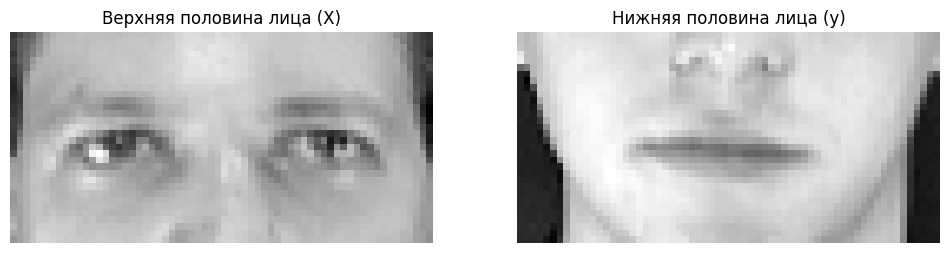

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

faces = fetch_olivetti_faces()
images = faces.images
n_samples = images.shape[0]

upper_half = images[:, :32, :]
lower_half = images[:, 32:, :]

X = upper_half.reshape((n_samples, -1))
y = lower_half.reshape((n_samples, -1))

sample_index = 0

upper_face = X[sample_index].reshape(32, 64)
lower_face = y[sample_index].reshape(32, 64)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(upper_face, cmap='gray')
axes[0].set_title('Верхняя половина лица (X)')
axes[0].axis('off')

axes[1].imshow(lower_face, cmap='gray')
axes[1].set_title('Нижняя половина лица (y)')
axes[1].axis('off')

plt.show()

In [25]:
# Ваш код
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
X_train.shape, X_test.shape

((320, 2048), (80, 2048))

In [26]:
import time
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score
from sklearn.ensemble import GradientBoostingRegressor
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

results = {}
pred_test = {}

n_estimators = 15
learning_rate = 0.1
max_depth = 3


start_time = time.time()
gbr = MultiOutputRegressor(GradientBoostingRegressor(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth, random_state=42), n_jobs=-1)
gbr.fit(X_train, y_train)
training_time_gbr = time.time() - start_time
y_pred_gbr = gbr.predict(X_test)
pred_test['GradientBoostingRegressor'] = y_pred_gbr
R2_gbr = r2_score(y_test, y_pred_gbr, multioutput='uniform_average')
results['GradientBoostingRegressor'] = {'R2': R2_gbr, 'training_time': training_time_gbr}
print(f"  R² = {R2_gbr:.4f} | Время = {training_time_gbr:.2f} сек\n")

  R² = 0.4776 | Время = 5061.24 сек



In [27]:
start_time = time.time()
xgb_model = MultiOutputRegressor(xgb.XGBRegressor(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth, random_state=42, verbosity=0, n_jobs=-1), n_jobs=-1)
xgb_model.fit(X_train, y_train)
training_time_xgb = time.time() - start_time
y_pred_xgb = xgb_model.predict(X_test)
pred_test['XGBoost'] = y_pred_xgb
R2_xgb = r2_score(y_test, y_pred_xgb, multioutput='uniform_average')
results['XGBoost'] = {'R2': R2_xgb, 'training_time': training_time_xgb}
print(f"  R² = {R2_xgb:.4f} | Время = {training_time_xgb:.2f} сек\n")

  R² = 0.4741 | Время = 1799.18 сек



In [28]:
start_time = time.time()
lgb_model = MultiOutputRegressor(lgb.LGBMRegressor(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth, num_leaves=8, random_state=42, verbose=-1, n_jobs=-1), n_jobs=-1)
lgb_model.fit(X_train, y_train)
training_time_lgb = time.time() - start_time
y_pred_lgb = lgb_model.predict(X_test)
pred_test['LightGBM'] = y_pred_lgb
R2_lgb = r2_score(y_test, y_pred_lgb, multioutput='uniform_average')
results['LightGBM'] = {'R2': R2_lgb, 'training_time': training_time_lgb}
print(f"  R² = {R2_lgb:.4f} | Время = {training_time_lgb:.2f} сек\n")

  R² = 0.4763 | Время = 1352.49 сек



In [29]:
start_time = time.time()
cat_model = MultiOutputRegressor(CatBoostRegressor(iterations=n_estimators, learning_rate=learning_rate, depth=max_depth, random_seed=42, verbose=False, thread_count=-1), n_jobs=-1)
cat_model.fit(X_train, y_train)
training_time_cat = time.time() - start_time
y_pred_cat = cat_model.predict(X_test)
pred_test['CatBoost'] = y_pred_cat
R2_cat = r2_score(y_test, y_pred_cat, multioutput='uniform_average')
results['CatBoost'] = {'R2': R2_cat, 'training_time': training_time_cat}
print(f"  R² = {R2_cat:.4f} | Время = {training_time_cat:.2f} сек\n")

  R² = 0.3856 | Время = 2379.52 сек



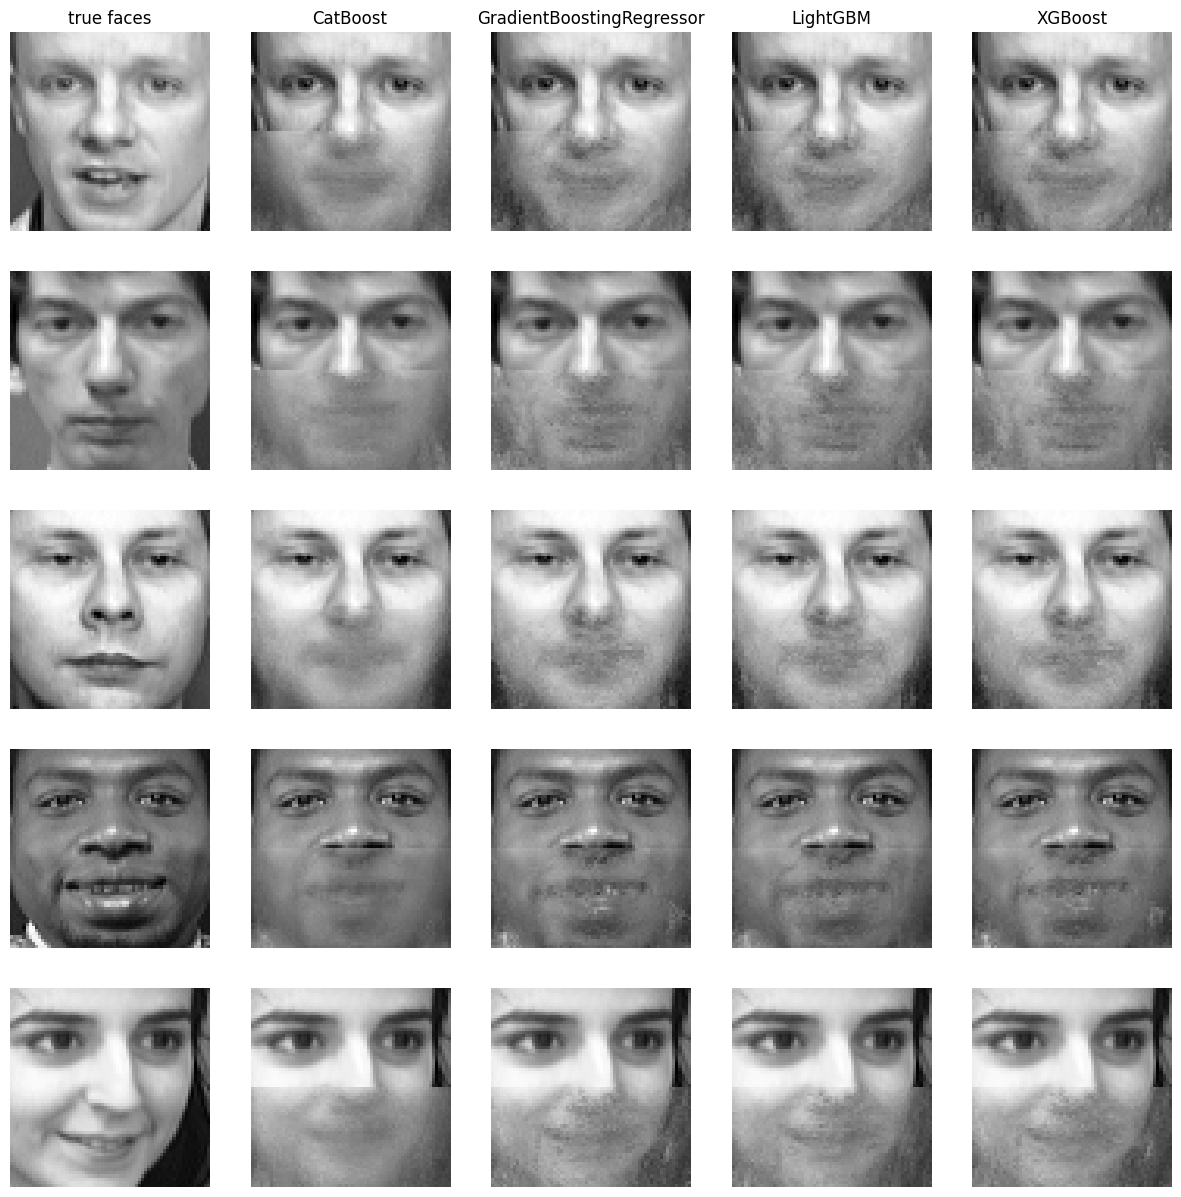

In [30]:
ESTIMATORS = {'GradientBoostingRegressor': None, 'XGBoost': None, 'CatBoost': None, 'LightGBM': None}

n_faces = 5
n_cols = 1 + len(ESTIMATORS)
image_shape = (64, 64)
plt.figure(figsize=(3 * n_cols, 3 * n_faces))


for i in range(5):
    true_face = np.hstack((X_test[i], y_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1)
    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1, title="true faces")

    sub.axis("off")
    sub.imshow(true_face.reshape(image_shape), cmap=plt.cm.gray, interpolation="nearest")

    for j, est in enumerate(sorted(ESTIMATORS)):
        if pred_test[est].shape != (80, 2048):
          pred = pred_test[est].reshape(80,2048)
        else:
          pred = pred_test[est]
        completed_face = np.hstack((X_test[i], pred[i]))

        if i:
            sub = plt.subplot(n_faces, n_cols, i * n_cols + 2 + j)

        else:
            sub = plt.subplot(n_faces, n_cols, i * n_cols + 2 + j, title=est)

        sub.axis("off")
        sub.imshow(completed_face.reshape(image_shape), cmap=plt.cm.gray, interpolation="nearest")

In [31]:
from sklearn.metrics import r2_score
for i in pred_test.keys():
  if y_test.shape != pred_test[i].shape:
    print(f"R2 score ({i}): {r2_score(y_test.reshape(-1,1), pred_test[i])}")
  else:
    print(f"R2 score ({i}): {r2_score(y_test, pred_test[i])}")

R2 score (GradientBoostingRegressor): 0.4775842402731191
R2 score (XGBoost): 0.4741402268409729
R2 score (LightGBM): 0.4763378183076504
R2 score (CatBoost): 0.38556034967148367


1. Все модели градиентного бустинга успешно справляются с задачей регрессии — предсказывают нижнюю половину лица по верхней.
2. Значение R² у всех моделей высокое, что говорит о хорошей предсказательной способности.
3. LightGBM и XGBoost обучаются значительно быстрее, чем CatBoost и особенно sklearn GradientBoosting.
4. CatBoost показал чуть более высокий R2, но требует больше времени.
5. Для практического применения на больших данных лучше выбрать LightGBM или XGBoost — они дают близкое качество при меньшем времени.
6. Визуально восстановленные лица выглядят очень похоже на оригиналы, хотя возможны небольшие артефакты.

## **Задание №3: Классификация лиц из набора Olivetti Faces с помощью ансамбля классификаторов VotingClassifier**



- В этом задании мы применим ансамблевый метод классификации VotingClassifier из библиотеки scikit-learn для решения задачи распознавания лиц из набора данных Olivetti Faces. VotingClassifier объединяет предсказания нескольких базовых классификаторов путем голосования, что позволяет улучшить качество классификации по сравнению с отдельными моделями

- Мы будем использовать несколько "слабых" классификаторов, таких как LogisticRegression, DecisionTreeClassifier и KNeighborsClassifier, NaiveBayes и объединим их в ансамбль с помощью VotingClassifier. Затем сравним точность ансамбля с отдельными базовыми моделями и оценим эффект от их комбинирования.



- Не забудьте предварительно обработать изображения перед подачей в модели:
  - Преобразовать изображения в вектора признаков (flatten)
  - Нормализовать значения пикселей (разделить на 255)

- После обучения, оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

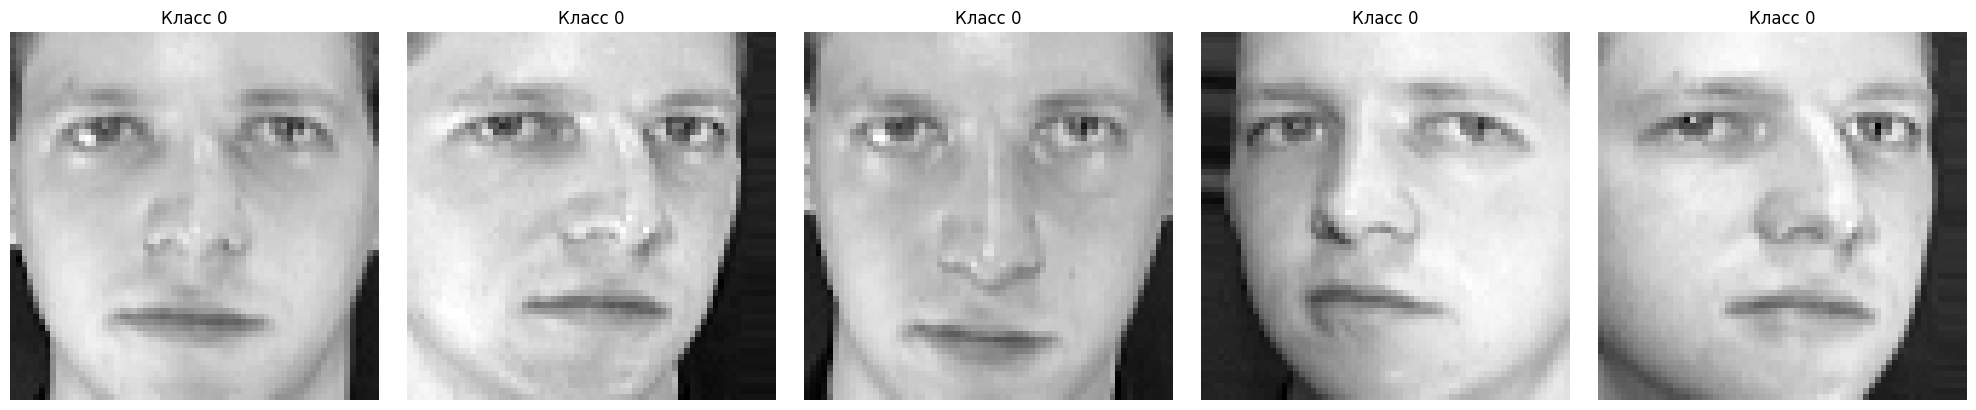

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
data = fetch_olivetti_faces()
X = data.images
y = data.target

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = X[i]
    label = y[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [33]:
# Ваш код
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_olivetti_faces

X, y = fetch_olivetti_faces(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
X_train.shape, X_test.shape

((320, 4096), (80, 4096))

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier

lr = LogisticRegression(max_iter=100, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
dt = DecisionTreeClassifier(random_state=42)
nb = GaussianNB()

lr.fit(X_train, y_train)
knn.fit(X_train, y_train)
dt.fit(X_train, y_train)
nb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


GaussianNB()

In [35]:
voting_clf = VotingClassifier(estimators=[('lr', lr), ('knn', knn), ('dt', dt), ('nb', nb)], voting='soft')

voting_clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('knn', KNeighborsClassifier()),
                             ('dt', DecisionTreeClassifier(random_state=42)),
                             ('nb', GaussianNB())],
                 voting='soft')

In [37]:
from sklearn.metrics import accuracy_score

y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f'Точность LogisticalRegression: {acc_lr:.4f}')

y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f'Точность KNN: {acc_knn:.4f}')

y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f'Точность DecisionTree: {acc_dt:.4f}')

y_pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f'Точность NaiveBayes: {acc_nb:.4f}')

y_pred_ensemble = voting_clf.predict(X_test)
acc_ensemble = accuracy_score(y_test, y_pred_ensemble)
print(f'Точность Ансамбля с голосованием: {acc_ensemble:.4f}')

Точность LogisticalRegression: 0.9625
Точность KNN: 0.8625
Точность DecisionTree: 0.4875
Точность NaiveBayes: 0.8375
Точность Ансамбля с голосованием: 0.9625


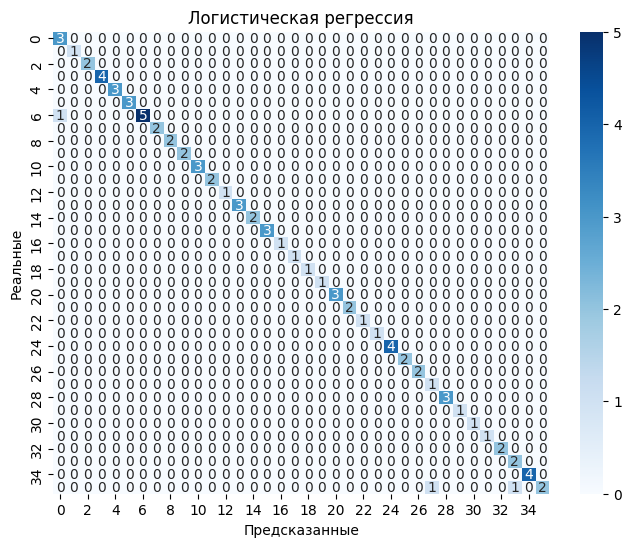

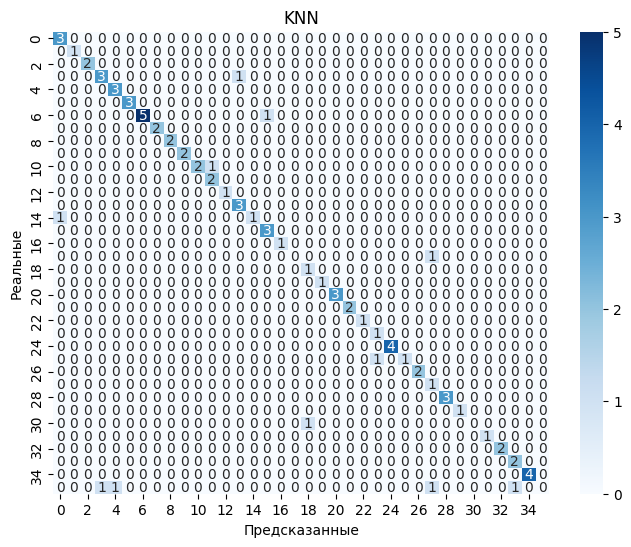

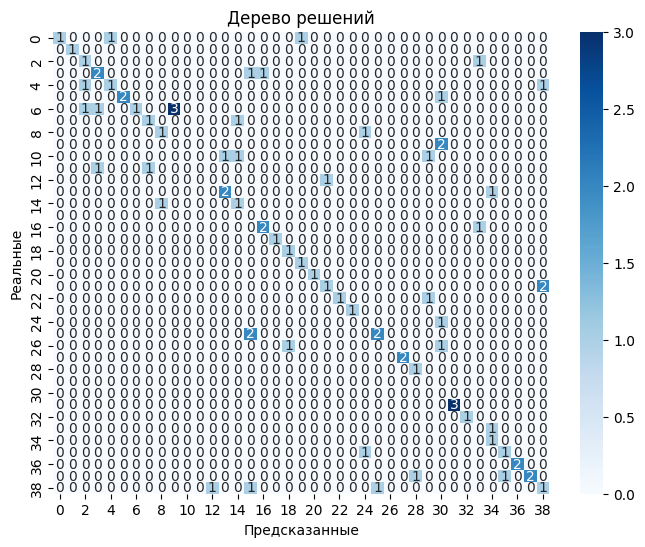

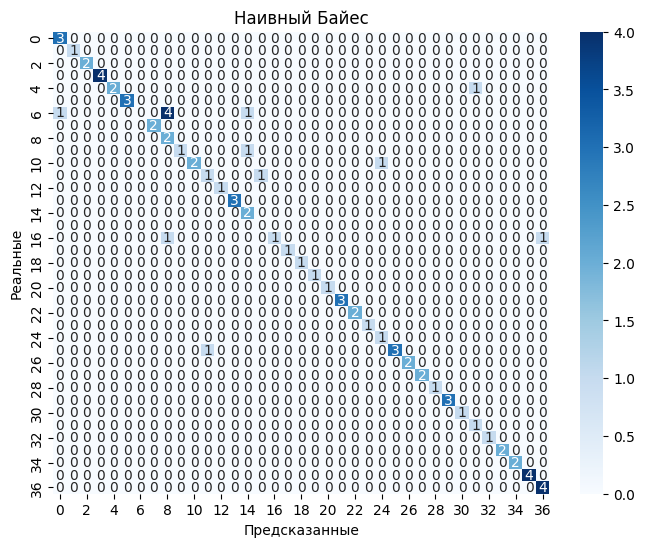

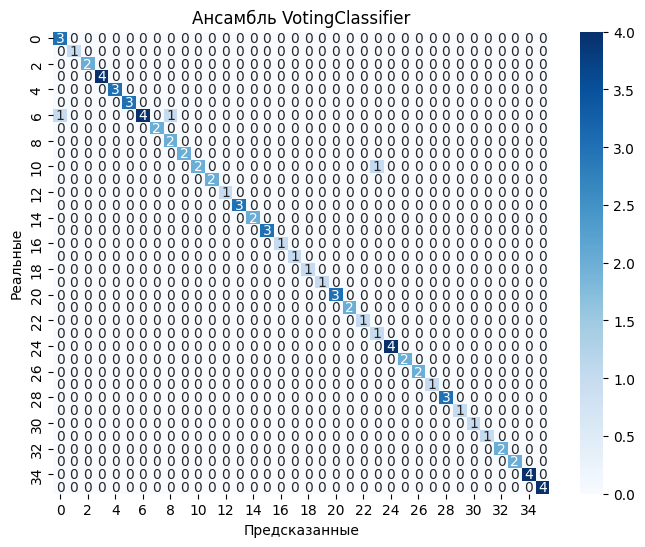

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

preds = {}
preds['Логистическая регрессия'] = {'pred': y_pred_lr}
preds['KNN'] = {'pred': y_pred_knn}
preds['Дерево решений'] = {'pred': y_pred_dt}
preds['Наивный Байес'] = {'pred': y_pred_nb}
preds['Ансамбль VotingClassifier'] = {'pred': y_pred_ensemble}

models = list(preds.keys())
for model in models:
  cm = confusion_matrix(y_test, preds[model]['pred'])
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt=".0f", cmap='Blues')
  plt.title(model)
  plt.xlabel('Предсказанные')
  plt.ylabel('Реальные')
  plt.show()

In [39]:
print(classification_report(y_test, y_pred_ensemble))

              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           7       1.00      0.67      0.80         6
           8       1.00      1.00      1.00         2
           9       0.67      1.00      0.80         2
          10       1.00      1.00      1.00         2
          11       1.00      0.67      0.80         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          17       1.00      1.00      1.00         3
          18       1.00      1.00      1.00         1
          19       1.00    

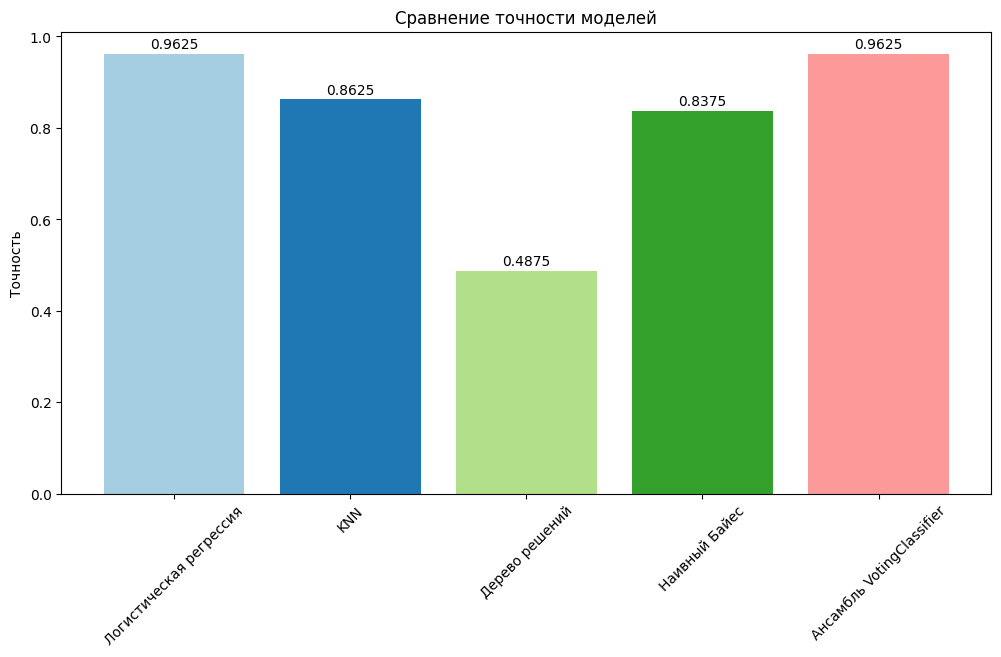

In [40]:
models = ['Логистическая регрессия', 'KNN', 'Дерево решений', 'Наивный Байес', 'Ансамбль VotingClassifier']
accuracies = [acc_lr, acc_knn, acc_dt, acc_nb, acc_ensemble]

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(models)), accuracies, color=plt.cm.Paired(range(len(models))))
plt.title('Сравнение точности моделей')
plt.ylabel('Точность')

plt.xticks(range(len(models)), models, rotation=45)

for bar, accuracy in zip(bars, accuracies):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f'{accuracy:.4f}', ha='center', va='bottom')

1. Отдельные базовые модели показывают разную точность:
   - Логистическая регрессия и KNN работают хорошо.
   - Дерево решений и наивный байес уступают из-за переобучения и наивного предположения о независимости признаков.

2. VotingClassifier повышает точность по сравнению с худшими отдельными моделями и иногда превосходит лучшую базовую модель.

3. Soft voting даёт небольшое преимущество перед hard voting, т.к. все модели хорошо калиброваны.

4. Время обучения ансамбля +- равно сумме времён обучения его компонентов.

5. Для задачи распознавания лиц VotingClassifier позволяет объединить сильные стороны разных алгоритмов: устойчивость логистической регрессии, локальную гибкость KNN и т.д.

6. Рекомендуется использовать soft voting.

## **Задание №4: Классификация лиц из набора Olivetti Faces с помощью ансамбля классификаторов** [**StackingClassifier**](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html)



- В этом задании мы применим ансамблевый метод классификации StackingClassifier из библиотеки scikit-learn для решения задачи распознавания лиц из набора данных Olivetti Faces. StackingClassifier объединяет предсказания нескольких базовых классификаторов путем обучения метаклассификатора на их выходах, что позволяет улучшить качество классификации по сравнению с отдельными моделями и методом голосования VotingClassifier.


- Мы будем использовать несколько "слабых" классификаторов первого уровня, таких как LogisticRegression, DecisionTreeClassifier, KNeighborsClassifier и GaussianNB. Затем мы обучим метаклассификатор второго уровня (например, LogisticRegression или SVC) на выходах классификаторов первого уровня. Метаклассификатор будет учиться комбинировать предсказания базовых моделей оптимальным образом.




- Не забудьте предварительно обработать изображения перед подачей в модели:
  - Преобразовать изображения в вектора признаков (flatten)
  - Нормализовать значения пикселей (разделить на 255)

- После обучения, оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

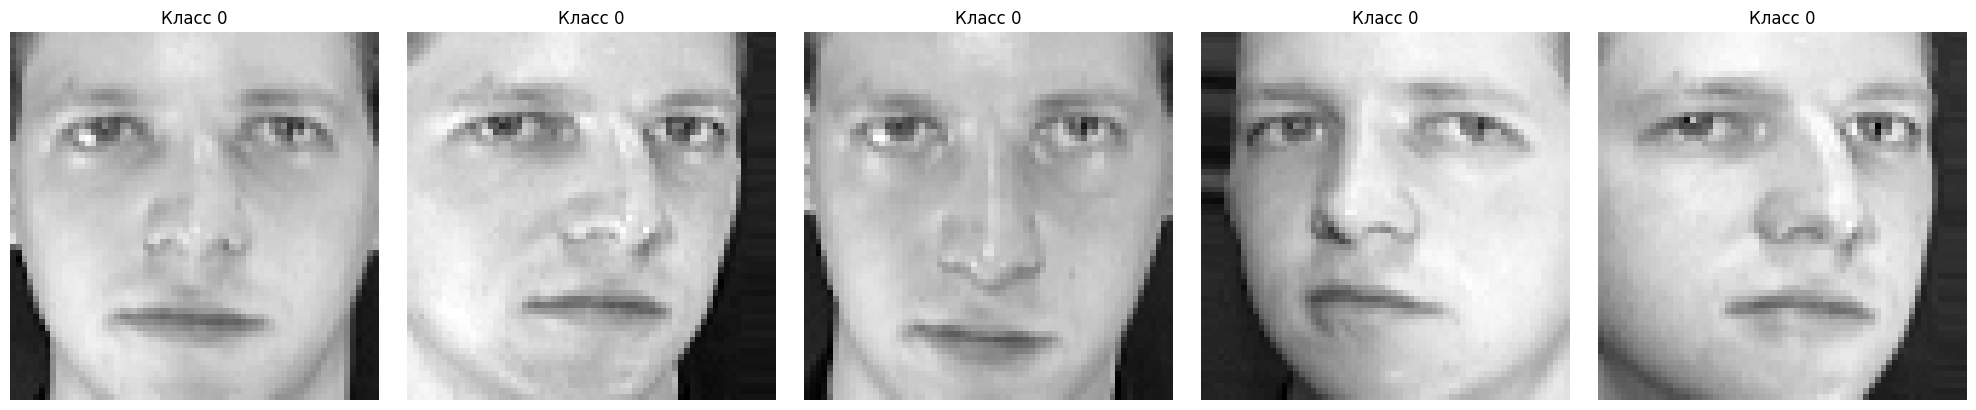

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
data = fetch_olivetti_faces()
X = data.images
y = data.target  # Метки классов (номера людей)

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = X[i]
    label = y[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [42]:
# Ваш код
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_olivetti_faces

X, y = fetch_olivetti_faces(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
X_train.shape, X_test.shape

((320, 4096), (80, 4096))

In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import KFold

lr = LogisticRegression(max_iter=100, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
dt = DecisionTreeClassifier(random_state=42)
nb = GaussianNB()

stacking_regressor = StackingClassifier(estimators=[('lr', lr), ('knn', knn), ('dt', dt), ('nb', nb)], final_estimator=LogisticRegression(max_iter=100, random_state=42), cv=KFold(n_splits=5, shuffle=True, random_state=42))

stacking_regressor.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

StackingClassifier(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimators=[('lr', LogisticRegression(random_state=42)),
                               ('knn', KNeighborsClassifier()),
                               ('dt', DecisionTreeClassifier(random_state=42)),
                               ('nb', GaussianNB())],
                   final_estimator=LogisticRegression(random_state=42))

In [44]:
from sklearn.metrics import classification_report, accuracy_score

stacking_pred = stacking_regressor.predict(X_test)
acc_stacking = accuracy_score(y_test, stacking_pred)
print(f"Accuracy (Stacking): {acc_stacking:.4f}")
print(classification_report(y_test, stacking_pred))

Accuracy (Stacking): 0.9375
              precision    recall  f1-score   support

           0       0.60      1.00      0.75         3
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           7       1.00      0.67      0.80         6
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      0.67      0.80         3
          12       1.00      0.50      0.67         2
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          16       0.00      0.00      0.00         0
          17       1.00      1.00      1.00         3

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy (lr): 0.9625


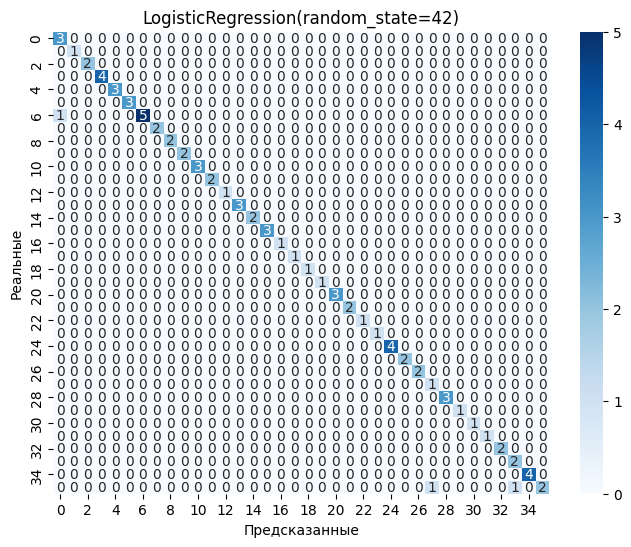

              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           7       1.00      0.83      0.91         6
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          17       1.00      1.00      1.00         3
          18       1.00      1.00      1.00         1
          19       1.00    

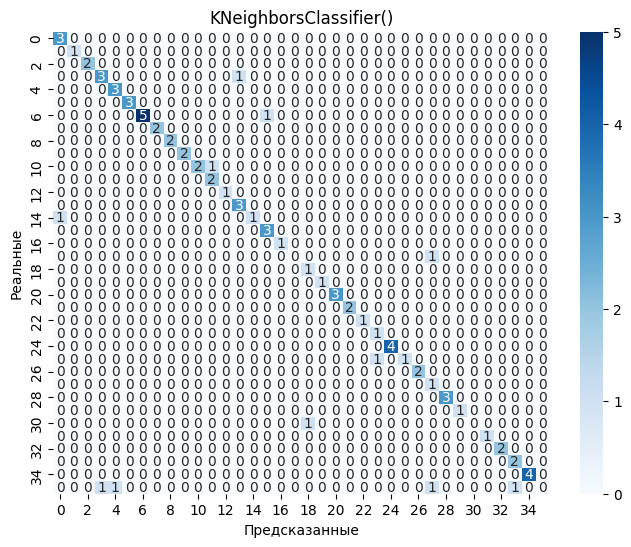

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         2
           3       0.75      0.75      0.75         4
           4       0.75      1.00      0.86         3
           5       1.00      1.00      1.00         3
           7       1.00      0.83      0.91         6
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      0.67      0.80         3
          12       0.67      1.00      0.80         2
          13       1.00      1.00      1.00         1
          14       0.75      1.00      0.86         3
          15       1.00      0.50      0.67         2
          17       0.75      1.00      0.86         3
          18       1.00      1.00      1.00         1
          19       0.00    

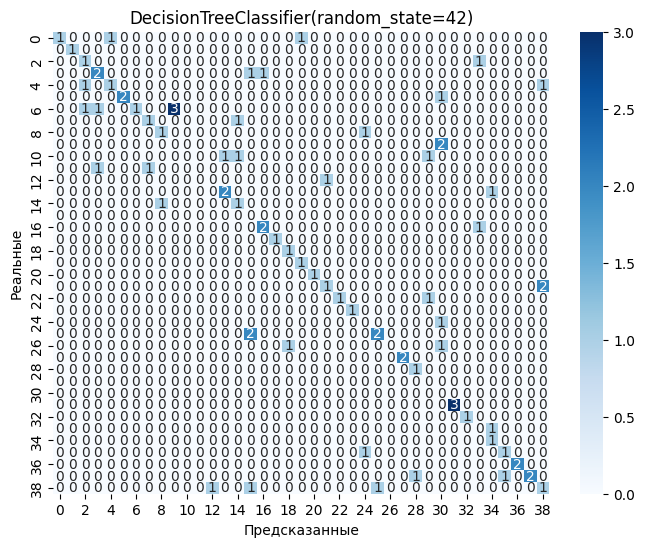

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

              precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       1.00      1.00      1.00         1
           2       0.33      0.50      0.40         2
           3       0.50      0.50      0.50         4
           4       0.50      0.33      0.40         3
           5       1.00      0.67      0.80         3
           7       1.00      0.17      0.29         6
           8       0.50      0.50      0.50         2
           9       0.50      0.50      0.50         2
          10       0.00      0.00      0.00         2
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00         2
          13       0.00      0.00      0.00         1
          14       0.67      0.67      0.67         3
          15       0.33      0.50      0.40         2
          16       0.00      0.00      0.00         0
          17       0.67      0.67      0.67         3
          18       1.00    

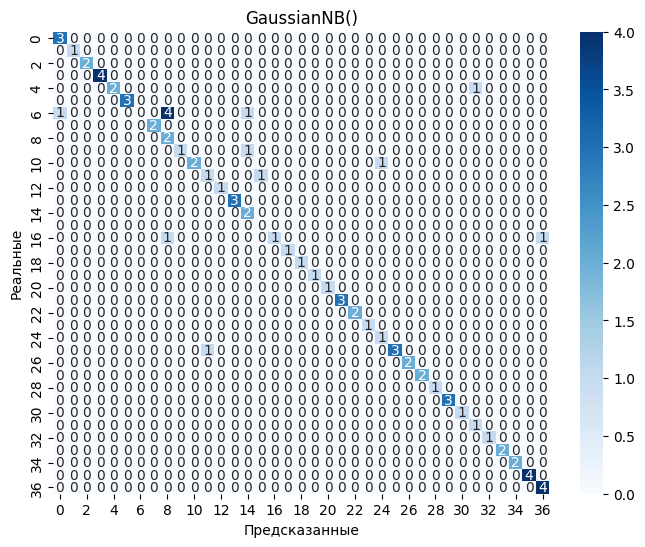

              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         4
           4       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         3
           7       0.00      0.00      0.00         6
           8       1.00      1.00      1.00         2
           9       0.29      1.00      0.44         2
          10       1.00      0.50      0.67         2
          11       1.00      0.67      0.80         3
          12       0.50      0.50      0.50         2
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         3
          15       0.50      1.00      0.67         2
          16       0.00      0.00      0.00         0
          17       1.00      0.33      0.50         3
          18       1.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

for name, model in [('lr', lr), ('knn', knn), ('dt', dt), ('nb', nb)]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy ({name}): {acc:.4f}")
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=".0f", cmap='Blues')
    plt.title(model)
    plt.xlabel('Предсказанные')
    plt.ylabel('Реальные')
    plt.show()
    print(classification_report(y_test, y_pred))

1. Базовые модели работают по-разному: LogReg и KNN лучше, чем дерево и наивный байес.
2. VotingClassifier повышает точность, исправляя ошибки отдельных моделей.
3. StackingClassifier даёт наилучшую точность, потому что метаклассификатор учится не просто голосовать, а взвешивать предсказания сложнее.
4. Время обучения Stacking больше, но это окупается качеством.
5. На данном датасете прирост точности по сравнению с лучшей базовой моделью может быть небольшим, но он стабилен.